# LDPC ECC

## Dependencies

In [12]:
!pip install stim~=1.15
!pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
!pip install scipy
!pip install pymatching~=2.0
!pip install sinter~=1.14


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import

In [13]:
import stim
import sinter
from typing import List

print(stim.__version__)

1.15.0


In [ ]:
def gen_ldpc_shift_matrix(d, k, data_anc_conn, anc_data_conn):
    H = [
        [1,1,1,1,0,0,0,0,0,0,0,0],
        [0,0,0,0,1,1,1,1,0,0,0,0],
        [0,0,0,0,0,0,0,0,1,1,1,1],
    ]
    # for i in k:
    #     for j in d:
    return H

def gen_ldpc_circuit(d, k, data_anc_conn, anc_data_conn, prob) -> stim.Circuit:
    H = gen_ldpc_shift_matrix(d,k,data_anc_conn,anc_data_conn)
    circuit = stim.Circuit()
    data = list(range(d))
    anc = list(range(d,2*d-k))
    print(f"data : {data}  anc: {anc}")
    circuit.append("R", data + anc)
    circuit.append("X_ERROR", data, prob)
    circuit.append("H", anc)
    for i in range(0, d-k):
        for j in range(0, d):
            if(H[i][j] == 1):
                circuit.append("CZ", [anc[i], j])
        circuit.append("H", anc[i])
        circuit.append("M", anc[i])
        circuit.append("DETECTOR", [stim.target_rec(-1)])
    
    circuit.append("M", data)
    circuit.append(
        "OBSERVABLE_INCLUDE",
        [stim.target_rec(),
         stim.target_rec(),
         stim.target_rec()],
         0
    )
    return circuit

data : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  anc: [12, 13, 14]


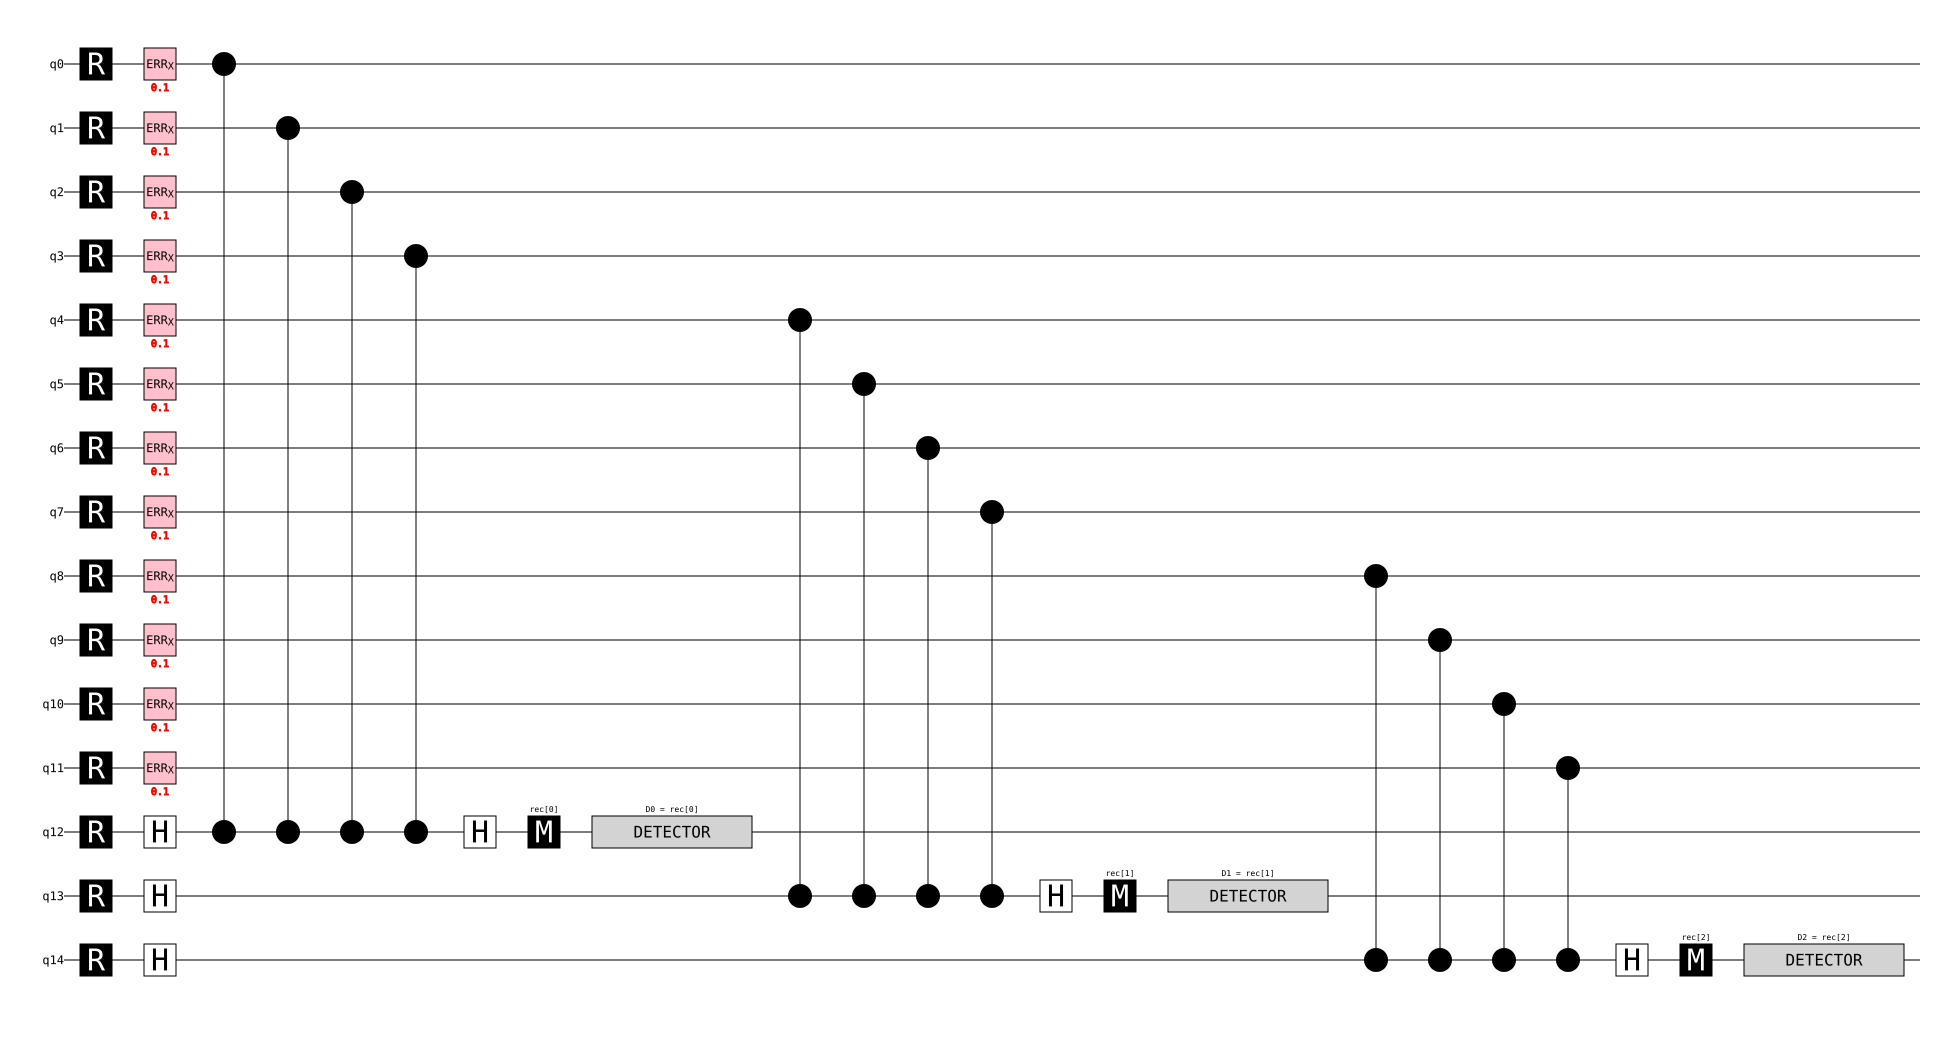

In [23]:
circuit = gen_ldpc_circuit(12,9,0,0, 0.1)
circuit.diagram('timeline-svg')